CELL 1 — Imports

In [37]:
import shap
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pymongo import MongoClient
import os
from dotenv import load_dotenv

load_dotenv()


True

CELL 2 — Load trained model (BEST model only)

In [39]:
MODEL_PATH = "../models/best_aqi_model.pkl"

model = joblib.load(MODEL_PATH)
type(model)


sklearn.linear_model._base.LinearRegression

CELL 3 — Load feature data from MongoDB (Feature Store)

In [40]:
FEATURE_COLUMNS = [
    "pm2_5",
    "pm10",
    "hour",
    "day",
    "month",
    "day_of_week",
    "aqi_lag_1",
    "aqi_lag_3",
    "aqi_lag_6",
    "aqi_lag_12",
    "aqi_lag_24",
    "aqi_change_rate",
    "rolling_24h_mean"
]

client = MongoClient(os.getenv("MONGODB_URI"))
db = client[os.getenv("MONGODB_DB")]
collection = db[os.getenv("MONGODB_COLLECTION")]

df = pd.DataFrame(list(collection.find())).drop(columns=["_id"])

X = df[FEATURE_COLUMNS]
X.head()


,pm2_5,pm10,hour,day,month,day_of_week,aqi_lag_1,aqi_lag_3,aqi_lag_6,aqi_lag_12,aqi_lag_24,aqi_change_rate,rolling_24h_mean
0,17.3,26.5,5,27,1,1,76.0,77.0,78.0,82.0,71.0,-1.0,77.375000
1,22.8,27.3,12,27,1,1,72.0,73.0,75.0,78.0,72.0,0.0,77.708333
2,17.5,27.2,3,27,1,1,77.0,78.0,79.0,72.0,70.0,0.0,77.000000
3,17.3,24.9,6,27,1,1,75.0,77.0,78.0,95.0,71.0,0.0,77.541667
4,22.2,28.1,13,27,1,1,72.0,72.0,74.0,77.0,72.0,0.0,77.708333


In [41]:
X_clean = X.dropna()


In [42]:
X_clean.shape


(191, 13)

CELL 4 — Create SHAP explainer

In [43]:
explainer = shap.Explainer(model, X)
shap_values = explainer(X)


CELL 5 — GLOBAL feature importance

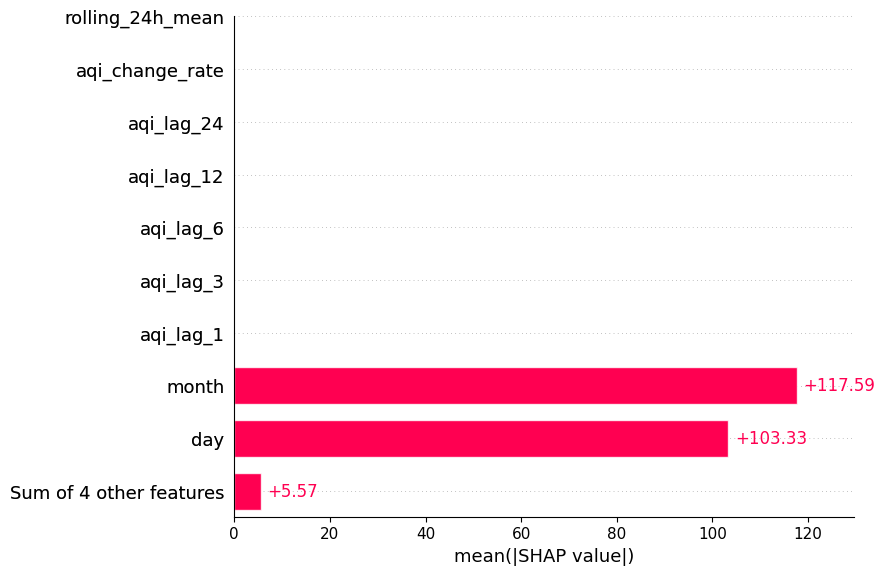

In [44]:
shap.plots.bar(shap_values, max_display=10)


CELL 6 — SHAP summary plot

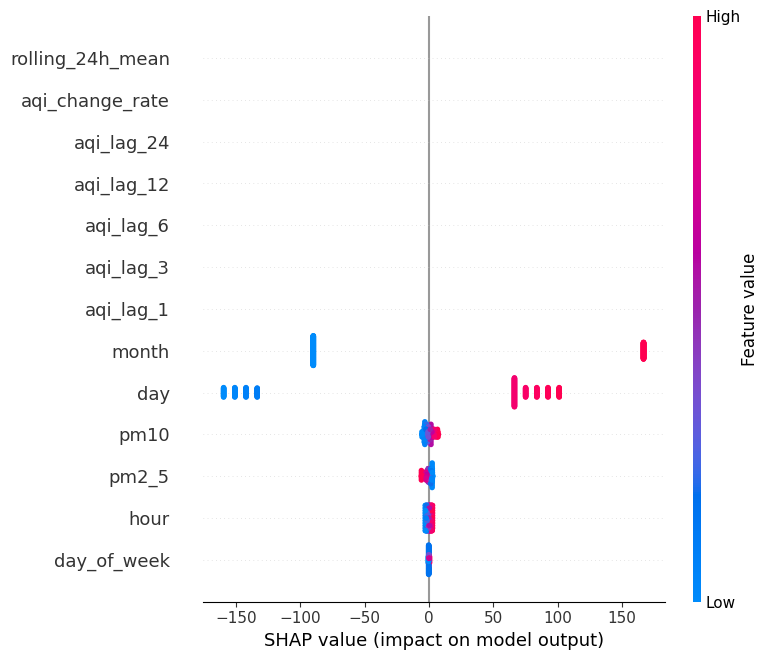

In [45]:
shap.summary_plot(shap_values, X)


CELL 7 — LOCAL explanation

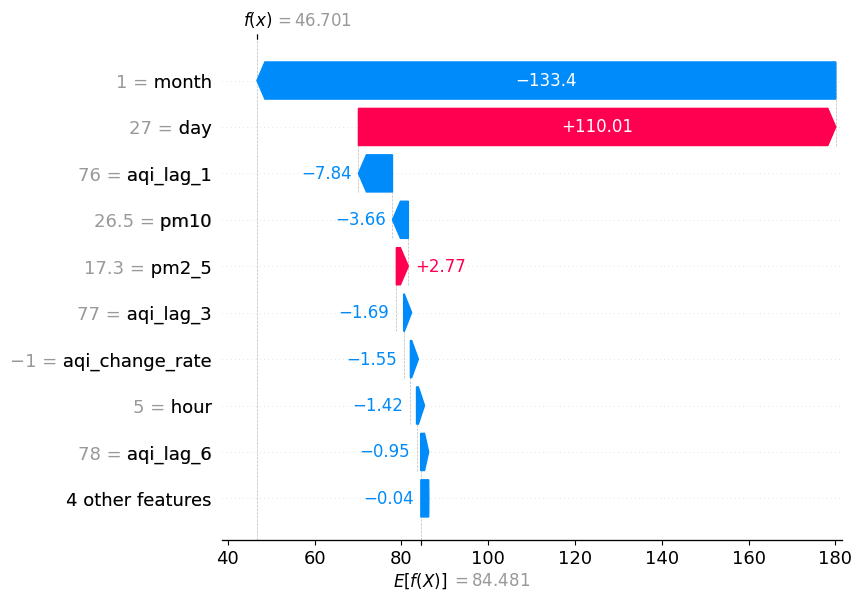

In [46]:
row = X_clean.iloc[[0]]  # double brackets important

explainer = shap.Explainer(model, X_clean)
shap_values = explainer(row)

shap.plots.waterfall(shap_values[0])

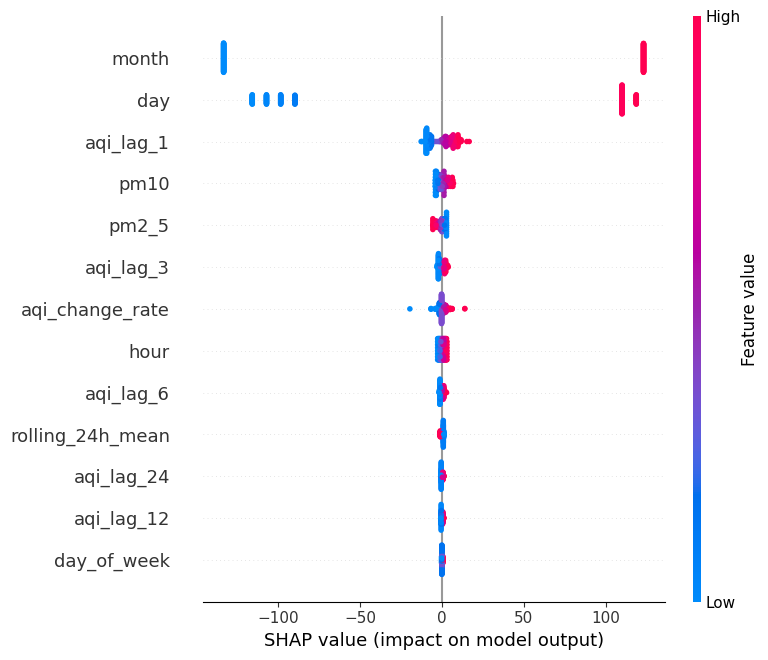

In [47]:
shap_values = explainer(X_clean)

shap.summary_plot(shap_values, X_clean)


CELL 8 — Save SHAP values for dashboard use

In [48]:
# Save mean absolute SHAP values (global importance)
shap_importance = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "importance": np.abs(shap_values.values).mean(axis=0)
}).sort_values("importance", ascending=False)

shap_importance.to_csv("../models/shap_feature_importance.csv", index=False)

shap_importance.head()


,feature,importance
4,month,128.298178
3,day,107.622822
6,aqi_lag_1,6.969621
1,pm10,2.382911
0,pm2_5,1.644592
